# **Phần 1 - Bài toán Hồi quy (Regression)**
## **1. Import thư viện & hàm**

In [277]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, QuantileTransformer, MinMaxScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from utils import read_data, drop_unnecessary_columns, filter_and_clean_order_status, initialize_target_variable,handle_duplicates
from utils import optimize_logistics_timestamps, fill_product_specs_smart, handle_category_missing, standardize_column_formats
from utils import handle_outliers_pipeline, visualize_outliers, plot_violin_comparison
from utils import merge_geolocation_and_calculate_distance, calculate_full_vif

## **2. Định nghĩa đường dẫn**

In [278]:
# Đường dẫn tương đối của file dữ liệu
path = "../../data/"
# Kiểm tra đường dẫn có tồn tại không 
if not os.path.exists(path):
    print(f"Đường dẫn {path} không tồn tại.")
else:
    print(f"Đường dẫn {path} tồn tại.")

Đường dẫn ../../data/ tồn tại.


## **3. Mô tả dữ liệu** 
### **a. Orders Data**

Bảng này chứa thông tin về các đơn hàng được khách hàng đặt trên các nền tảng thương mại điện tử. Mỗi dòng đại diện cho một đơn hàng riêng biệt của khách hàng 
<div align="center">

| Feature                          | Mô tả                                                                 |
|----------------------------------|----------------------------------------------------------------------|
| order_id                         | Mã định danh duy nhất cho mỗi đơn hàng                              |
| customer_id                      | Mã định danh duy nhất của khách hàng đặt đơn                        |
| order_status                     | Trạng thái hiện tại của đơn hàng (ví dụ: đã giao, đang giao, đã hủy)|
| order_purchase_timestamp         | Thời điểm khách hàng đặt đơn hàng                                   |
| order_approved_at                | Thời điểm đơn hàng được xác nhận                                    |
| order_delivered_carrier_date     | Thời điểm đơn hàng được bàn giao cho đơn vị vận chuyển              |
| order_delivered_customer_date    | Thời điểm đơn hàng được giao đến khách hàng                         |
| order_estimated_delivery_date    | Ngày dự kiến giao hàng                                              |
</div>

In [279]:
orders_df = read_data(path, "olist_orders_dataset.csv")
print('Orders Data Shape: ',orders_df.shape)
display(orders_df.head())
print("Orders Data Info:")
display(orders_df.info())

Đang đọc dữ liệu từ olist_orders_dataset.csv...
Orders Data Shape:  (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Orders Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


None

### **b. Orders items**

Bảng này chứa thông tin về các mặt hàng được đặt mua trong hệ thống thương mại điện tử. Mỗi hàng đại diện cho một mặt hàng trong một đơn đặt hàng.
<div align='center'>

| Feature              | Mô tả                                                                 |
|---------------------|----------------------------------------------------------------------|
| order_id            | Mã định danh duy nhất của đơn hàng                                   |
| order_item_id       | Số thứ tự của từng sản phẩm trong cùng một đơn hàng                  |
| product_id          | Mã định danh duy nhất của sản phẩm                                   |
| seller_id           | Mã định danh duy nhất của người bán sản phẩm                         |
| shipping_limit_date | Hạn chót để sản phẩm được gửi đi                                    |
| price               | Giá của sản phẩm                                                     |
| freight_value       | Chi phí vận chuyển của sản phẩm                                     |

</div>

In [280]:
order_items_df = read_data(path, "olist_order_items_dataset.csv")
print("Orders items Data Shape: ", order_items_df.shape)
display(order_items_df.head())
print("Orders items Data Info:")
display(order_items_df.info())  

Đang đọc dữ liệu từ olist_order_items_dataset.csv...
Orders items Data Shape:  (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Orders items Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


None

### **c. Customers** 

Bảng này chứa thông tin về khách hàng. Mỗi hàng trong bảng đại diện cho một khách hàng, mỗi khách hàng được xác định bằng các thuộc tính hoặc đặc điểm được thể hiện bởi các cột trong bảng.
<div align='center'>

| Feature                    | Mô tả                                                                 |
|---------------------------|----------------------------------------------------------------------|
| customer_id               | Mã định danh duy nhất cho mỗi lần giao dịch hoặc tương tác của khách hàng |
| customer_unique_id        | Mã định danh duy nhất cho mỗi khách hàng                             |
| customer_zip_code_prefix  | Tiền tố mã bưu điện của địa chỉ khách hàng                          |
| customer_city             | Thành phố của khách hàng                                             |
| customer_state            | Bang (khu vực) của khách hàng                                        |

</div>

In [281]:
customers_df = read_data(path, "olist_customers_dataset.csv")   
print("Customers Data Shape: ", customers_df.shape)
display(customers_df.head())
print("Customers Data Info:")
display(customers_df.info())  

Đang đọc dữ liệu từ olist_customers_dataset.csv...
Customers Data Shape:  (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Customers Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None

### **d. Sellers**

Bảng này cung cấp thông tin về người bán đã đăng ký ở trên nền tảng bán hàng. Mỗi dòng mô tả chi tiết về một người bán 
<div align='center'>

| Feature                 | Mô tả                                                           |
|------------------------|-----------------------------------------------------------------|
| seller_id              | Mã định danh duy nhất cho mỗi người bán                         |
| seller_zip_code_prefix | Tiền tố mã bưu điện của địa chỉ người bán                      |
| seller_city            | Thành phố nơi người bán hoạt động                               |
| seller_state           | Bang (khu vực) nơi người bán hoạt động                          |

</div>

In [282]:
sellers_df = read_data(path, "olist_sellers_dataset.csv")
print("Sellers Data Shape: ", sellers_df.shape)
display(sellers_df.head())
print("Sellers Data Info:")
display(sellers_df.info())


Đang đọc dữ liệu từ olist_sellers_dataset.csv...
Sellers Data Shape:  (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Sellers Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


None

### **e. Products**

Bảng này chứa tập hợp dữ liệu sản phẩm từ các nền tảng thương mại điện tử, bao gồm thông tin về nhiều sản phẩm khác nhau như mô tả sản phẩm hoặc kích thước.
<div align='center'>

| Feature                        | Mô tả                                                                 |
|--------------------------------|----------------------------------------------------------------------|
| product_id                     | Mã định danh duy nhất của sản phẩm                                   |
| product_category_name          | Danh mục mà sản phẩm thuộc về                                        |
| product_name_lenght            | Độ dài tên sản phẩm (số ký tự)                                       |
| product_description_lenght     | Độ dài mô tả sản phẩm (số ký tự)                                     |
| product_photos_qty             | Số lượng hình ảnh của sản phẩm                                       |
| product_weight_g               | Trọng lượng sản phẩm (tính bằng gram)                               |
| product_length_cm              | Chiều dài sản phẩm (cm)                                              |
| product_height_cm              | Chiều cao sản phẩm (cm)                                              |
| product_width_cm               | Chiều rộng sản phẩm (cm)                                             |

</div>

In [283]:
products_df = read_data(path, "olist_products_dataset.csv")
print("Products Data Shape: ", products_df.shape)
display(products_df.head())
print("Products Data Info:")
display(products_df.info())

Đang đọc dữ liệu từ olist_products_dataset.csv...
Products Data Shape:  (32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Products Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


None

### **f. Translation** 

Bảng này chứa tập dữ liệu dịch tên danh mục sản phẩm, được sử dụng để dịch tên danh mục sản phẩm từ tiếng Bồ Đào Nha sang tiếng Anh.
<div align='center'>

| Feature                         | Mô tả                                                      |
|---------------------------------|-----------------------------------------------------------|
| product_category_name           | Tên danh mục sản phẩm gốc bằng tiếng Bồ Đào Nha           |
| product_category_name_english   | Tên danh mục sản phẩm đã được dịch sang tiếng Anh         |

</div>

In [284]:
category_translation_df = read_data(path, "product_category_name_translation.csv")
print("Translation Data Shape: ", category_translation_df.shape)
display(category_translation_df.head())
print("Translation Data Info:")
display(category_translation_df.info())

Đang đọc dữ liệu từ product_category_name_translation.csv...
Translation Data Shape:  (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Translation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


None

### **g. Geolocation** 
Bảng này chứa dữ liệu xác định vị trí địa lý trong thế giới thực hoặc vị trí vật lý của các đối tượng khác nhau thông qua tọa độ GPS. Mỗi hàng đại diện cho một vị trí địa lý duy nhất.

<div align='center'>

| Feature                       | Mô tả                                                                 |
|-------------------------------|----------------------------------------------------------------------|
| geolocation_zip_code_prefix   | Tiền tố mã bưu điện (CEP) của Brazil cho một khu vực cụ thể          |
| geolocation_lat              | Tọa độ vĩ độ của vị trí                                             |
| geolocation_lng              | Tọa độ kinh độ của vị trí                                           |
| geolocation_city             | Tên thành phố tương ứng với vị trí địa lý                           |
| geolocation_state            | Tên bang (khu vực) tương ứng với vị trí địa lý                      |

</div>

In [285]:
geolocation_df = read_data(path, "olist_geolocation_dataset.csv")
print("Geolocation Data Shape: ", geolocation_df.shape)
display(geolocation_df.head())
print("Geolocation Data Info:")
display(geolocation_df.info())

Đang đọc dữ liệu từ olist_geolocation_dataset.csv...
Geolocation Data Shape:  (1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Geolocation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


None

## **4. Gộp và loại bỏ những cột dữ liệu không cần thiết**
- Gộp dữ liệu

In [286]:
# Merge các DataFrame lại với nhau
df = pd.merge(orders_df, customers_df, on='customer_id', how='left')
df = df.merge(order_items_df, on='order_id', how='left')
df = df.merge(sellers_df, on='seller_id', how='left')
df = df.merge(products_df, on='product_id', how='left')
df = df.merge(category_translation_df, on='product_category_name', how='left')

print('Merge Data Shape:',df.shape)
display(df.head())

Merge Data Shape: (113425, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,SP,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,SP,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,MG,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


- Xóa các cột dữ liệu không cần thiết 

In [287]:
df_raw = drop_unnecessary_columns(df)
print('Final Data Shape:', df_raw.shape)
display(df_raw.head())

ĐÃ LÀM SẠCH CỘT
 + Tổng số cột ban đầu: 30
 + Số cột đã bị loại bỏ: 10
 + Số cột còn lại: 20
Final Data Shape: (113425, 20)


,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3149,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,9350.0,maua,SP,500.0,19.0,8.0,13.0,housewares
1,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,47813,barreiras,BA,2018-07-30 03:24:27,118.70,22.76,31570.0,belo horizonte,SP,400.0,19.0,13.0,19.0,perfumery
2,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,75265,vianopolis,GO,2018-08-13 08:55:23,159.90,19.22,14840.0,guariba,SP,420.0,24.0,19.0,21.0,auto
3,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,59296,sao goncalo do amarante,RN,2017-11-23 19:45:59,45.00,27.20,31842.0,belo horizonte,MG,450.0,30.0,10.0,20.0,pet_shop
4,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,9195,santo andre,SP,2018-02-19 20:31:37,19.90,8.72,8752.0,mogi das cruzes,SP,250.0,51.0,15.0,15.0,stationery


- Chỉ giữ lại các dòng dữ liệu giao hàng thành công và xóa bỏ cột order_status

In [288]:
df_clean = filter_and_clean_order_status(df_raw)
print('Cleaned Data Shape:', df_clean.shape)
display(df_clean.head())

ĐÃ LỌC ĐƠN HÀNG
 + Tổng số đơn hàng ban đầu: 113425
 + Số đơn hàng đã bị loại bỏ (chưa giao hoặc lỗi ngày): 3236
 + Số đơn hàng còn lại: 110189
Cleaned Data Shape: (110189, 19)


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3149,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,9350.0,maua,SP,500.0,19.0,8.0,13.0,housewares
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,47813,barreiras,BA,2018-07-30 03:24:27,118.70,22.76,31570.0,belo horizonte,SP,400.0,19.0,13.0,19.0,perfumery
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,75265,vianopolis,GO,2018-08-13 08:55:23,159.90,19.22,14840.0,guariba,SP,420.0,24.0,19.0,21.0,auto
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,59296,sao goncalo do amarante,RN,2017-11-23 19:45:59,45.00,27.20,31842.0,belo horizonte,MG,450.0,30.0,10.0,20.0,pet_shop
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,9195,santo andre,SP,2018-02-19 20:31:37,19.90,8.72,8752.0,mogi das cruzes,SP,250.0,51.0,15.0,15.0,stationery


- Tính toán biến mục tiêu và lưu dữ liệu vào file csv

In [289]:
df_final = initialize_target_variable(df_clean)
df_final.to_csv(f"{path}raw_data.csv",index =False)

KHỞI TẠO BIẾN MỤC TIÊU 
- Số dòng bị loại bỏ (do thiếu ngày giao hoặc lỗi logic): 0
- Số lượng mẫu còn lại: 110189
- Thời gian giao hàng trung bình trong tập dữ liệu: 12.47 ngày


## **5. Thống kê mô tả dữ liệu sau khi gộp**

In [290]:
print(f"Kích thước của dữ liệu: {df_final.shape}")
df_final.info()

Kích thước của dữ liệu: (110189, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 0 to 113424
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_purchase_timestamp       110189 non-null  datetime64[ns]
 1   order_approved_at              110174 non-null  object        
 2   order_delivered_carrier_date   110188 non-null  object        
 3   order_delivered_customer_date  110189 non-null  datetime64[ns]
 4   order_estimated_delivery_date  110189 non-null  object        
 5   customer_zip_code_prefix       110189 non-null  int64         
 6   customer_city                  110189 non-null  object        
 7   customer_state                 110189 non-null  object        
 8   shipping_limit_date            110189 non-null  object        
 9   price                          110189 non-null  float64       
 10  freight_value                  11018

In [291]:
df_final.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,110189,2018-01-02 02:39:32.673823744,2016-09-15 12:16:38,2017-09-15 04:48:38,2018-01-21 09:13:44,2018-05-05 15:38:37,2018-08-29 15:00:37,NaN
order_delivered_customer_date,110189,2018-01-14 13:59:34.689261056,2016-10-11 13:46:32,2017-09-26 20:15:35,2018-02-02 21:05:09,2018-05-15 20:14:33,2018-10-17 13:22:46,NaN
customer_zip_code_prefix,110189.0,35156.229651,1003.0,11310.0,24344.0,59066.0,99980.0,29901.229067
price,110189.0,119.977937,0.85,39.9,74.9,134.17,6735.0,182.304615
freight_value,110189.0,19.948869,0.0,13.08,16.26,21.15,409.68,15.698615
seller_zip_code_prefix,110189.0,24468.450236,1001.0,6429.0,13568.0,28035.0,99730.0,27625.317906
product_weight_g,110171.0,2089.687813,0.0,300.0,700.0,1800.0,40425.0,3741.682542
product_length_cm,110171.0,30.142551,7.0,18.0,25.0,38.0,105.0,16.122279
product_height_cm,110171.0,16.555427,2.0,8.0,13.0,20.0,105.0,13.409562
product_width_cm,110171.0,22.986258,6.0,15.0,20.0,30.0,118.0,11.68796


## **6. Phân tích khám phá (EDA)**
### **a. Biểu đồ 1: Phân phối biến mục tiêu**

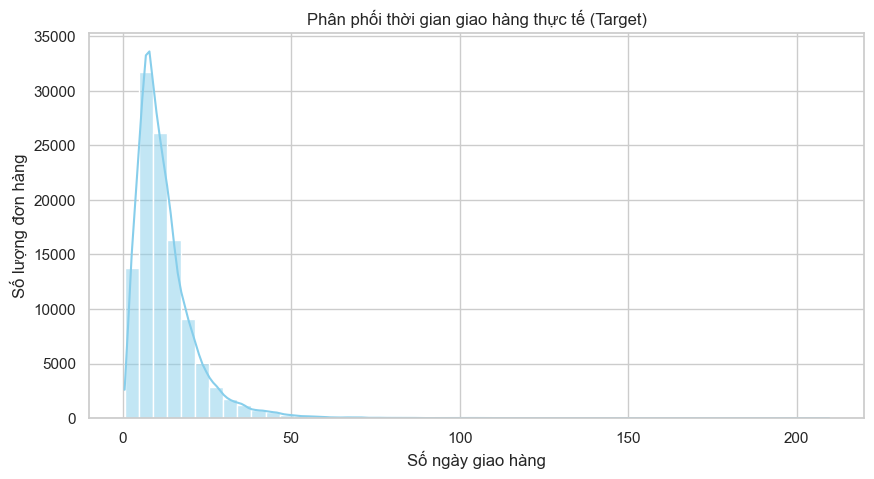

In [292]:
#df_final['order_purchase_timestamp'] = pd.to_datetime(df_final['order_purchase_timestamp'])
sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df_final['target_delivery_days'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối thời gian giao hàng thực tế (Target)')
plt.xlabel('Số ngày giao hàng')
plt.ylabel('Số lượng đơn hàng')
plt.show()

##### Nhận xét: Dữ liệu lệch phải. Đa số đơn hàng giao dưới 20 ngày.

### **b. Biểu đồ 2: Ma trận tương quan**

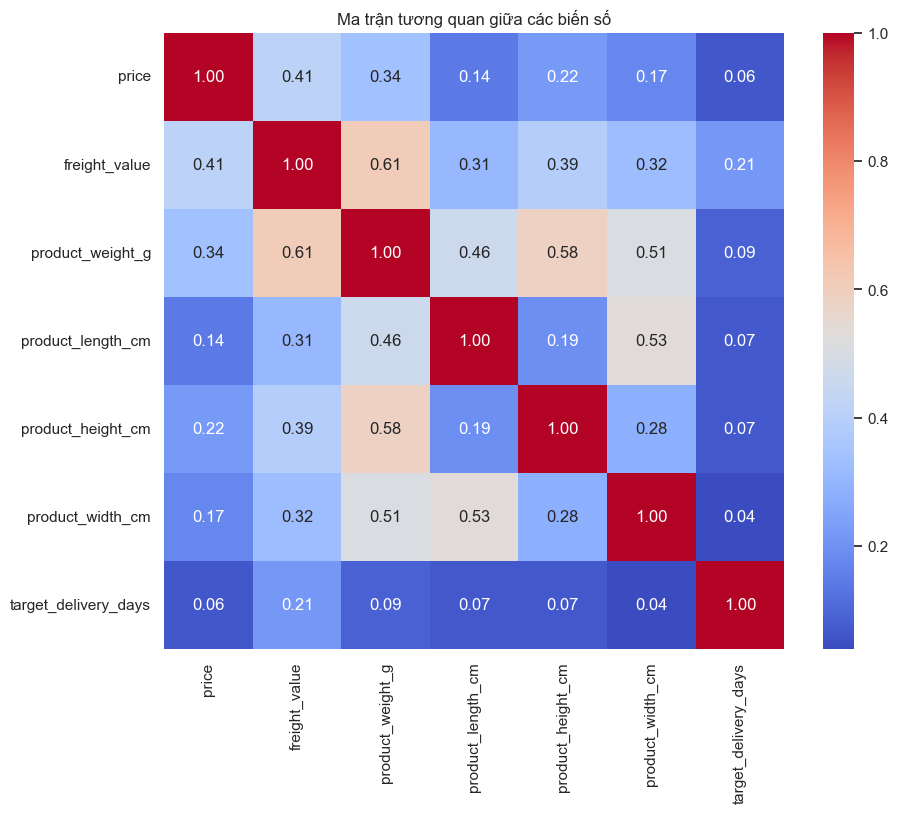

In [293]:
plt.figure(figsize=(10,8))
numerical_cols = ['price', 'freight_value', 'product_weight_g', 
                  'product_length_cm', 'product_height_cm', 
                  'product_width_cm', 'target_delivery_days']
sns.heatmap(df_final[numerical_cols].corr(), annot = True, cmap ='coolwarm', fmt ='.2f')
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

#### Nhận xét:
- 'freight_value' (phí ship) và 'product_weight_g' (trọng lượng) có tương quan thuận mạnh (0.61).
- 'price' không ảnh hưởng nhiều đến thời gian giao hàng.
### **c. Biểu đồ 3: Boxplot theo Bang**

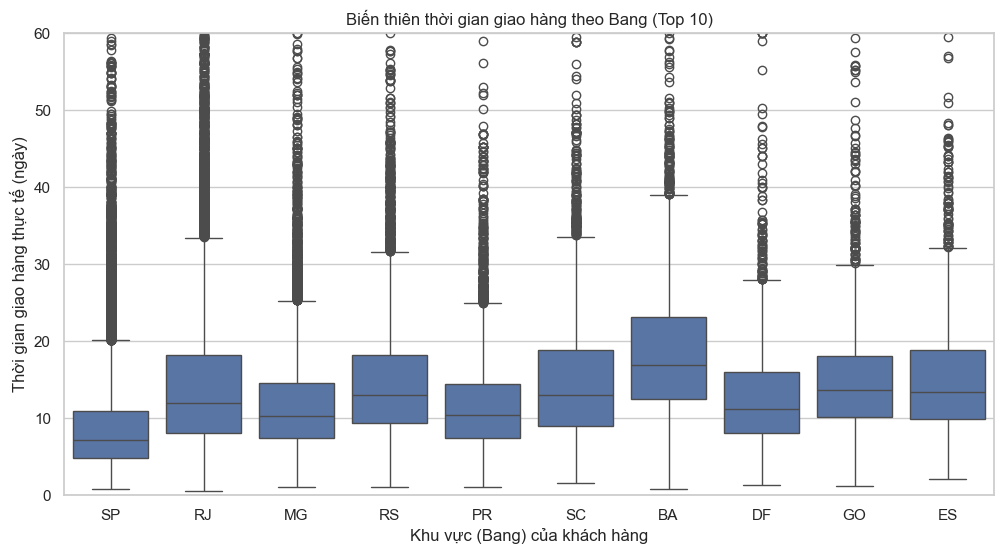

In [294]:
top_states = df_final['customer_state'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='customer_state', y='target_delivery_days', 
            data=df_final[df_final['customer_state'].isin(top_states)], order=top_states)
plt.title('Biến thiên thời gian giao hàng theo Bang (Top 10)')
plt.ylim(0, 60) 
plt.ylabel("Thời gian giao hàng thực tế (ngày)")
plt.xlabel("Khu vực (Bang) của khách hàng")
plt.show()

#### Nhận xét:
- Bang SP (Sao Paulo) có thời gian giao hàng nhanh và ổn định nhất.
- Các bang xa trung tâm như BA (Bahia) có thời gian giao hàng trung bình cao hơn và dải biến thiên rộng.
### **d. Biểu đồ 4: Xu hướng theo thời gian**

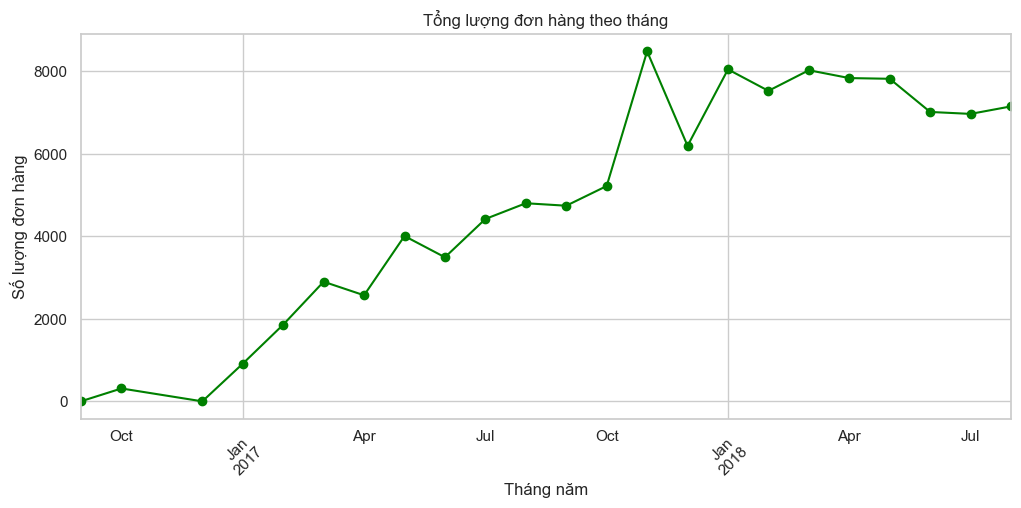

In [295]:
df_final['month_year'] = df_final['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df_final.groupby('month_year').size()
plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o', color='green')
plt.title('Tổng lượng đơn hàng theo tháng')
plt.xticks(rotation=45)
plt.ylabel("Số lượng đơn hàng")
plt.xlabel("Tháng năm")
plt.show()

##### Nhận xét: Lượng đơn hàng tăng trưởng đều theo thời gian, có đỉnh cao vào cuối năm 2017 (Black Friday).
#### **e. Biểu đồ 5: Top danh mục sản phẩm**

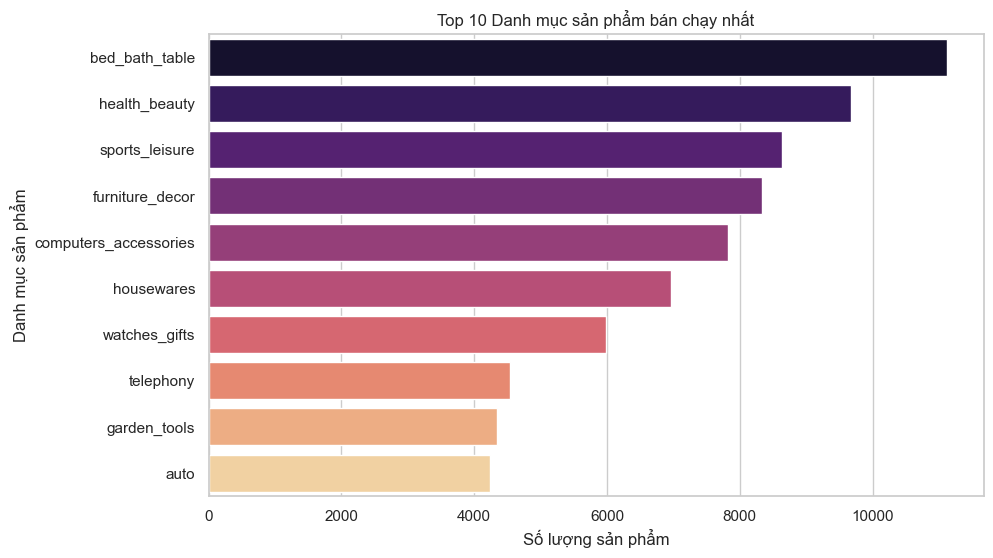

In [296]:
top_cats = df['product_category_name_english'].value_counts().nlargest(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_cats.values, 
    y=top_cats.index, 
    hue=top_cats.index, 
    palette='magma', 
    legend=False
)
plt.title('Top 10 Danh mục sản phẩm bán chạy nhất')
plt.ylabel('Danh mục sản phẩm')
plt.xlabel('Số lượng sản phẩm')
plt.show()

### **f. Thời gian giao hàng trung bình theo từng `Ngày` trong tuần**

C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_3520\924455341.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='order_weekday', y='target_delivery_days', data=df_final, order=weekday_order, palette='viridis')


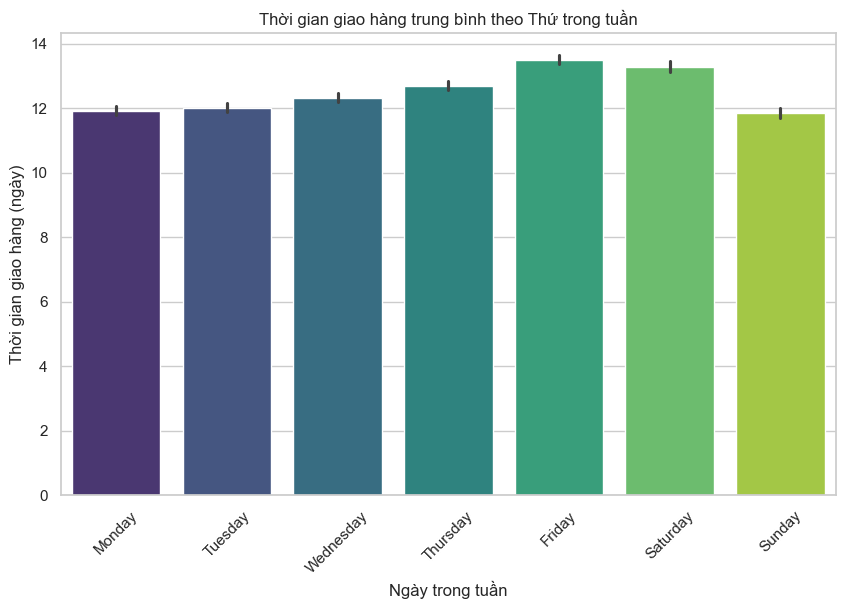

In [297]:
df_final['order_weekday'] = df_final['order_purchase_timestamp'].dt.day_name()
df_final['order_month'] = df_final['order_purchase_timestamp'].dt.month
# display(df_final['order_month'].head)
# display(df_final['order_weekday'].head)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10,6))
sns.barplot(x='order_weekday', y='target_delivery_days', data=df_final, order=weekday_order, palette='viridis')
plt.title('Thời gian giao hàng trung bình theo Thứ trong tuần')
plt.xlabel('Ngày trong tuần')
plt.ylabel('Thời gian giao hàng (ngày)')
plt.tick_params(axis='x', rotation=45)

#### `Nhận xét:` 
- Khi một khách hàng đặt mua vào Thứ 5 hoặc Thứ 6, đơn hàng cần 1-2 ngày để người bán đóng gói và giao cho đơn vị vận chuyển (carrier). Trớ trêu thay, lúc gói hàng bắt đầu đi vào trung tâm trung chuyển thì lại vướng ngay vào Thứ 7 và Chủ Nhật — hai ngày mà các công ty bưu chính (như Correios của Brazil) thường nghỉ việc hoặc giảm công suất tối đa. Hậu quả là gói hàng bị "đóng băng" lưu kho mất 2 ngày, làm tổng thời gian (tính theo ngày lịch) bị dội lên.

- Nếu khách đặt hàng vào Chủ Nhật, hệ thống sẽ ghi nhận và người bán có thể xử lý ngay vào sáng sớm Thứ 2. Gói hàng này sẽ có một đường băng dài trọn vẹn 5 ngày làm việc liên tục (Thứ 2 đến Thứ 6) để di chuyển xuyên bang mà không bị cản trở bởi ngày nghỉ nào.

### **g. Sự thay đổi của thời gian giao hàng theo `Tháng`**

([<matplotlib.axis.XTick at 0x21b06b47f90>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

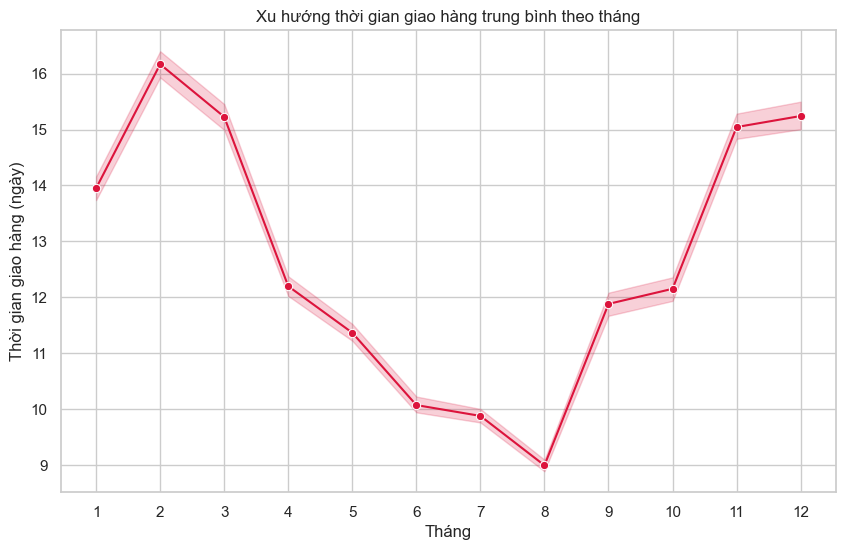

In [298]:
plt.figure(figsize=(10,6))
sns.lineplot(x='order_month', y='target_delivery_days', data=df_final, marker='o', color='crimson')
plt.title('Xu hướng thời gian giao hàng trung bình theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Thời gian giao hàng (ngày)')
plt.xticks(range(1,13))

#### `Nhận xét`
- Đỉnh điểm giao hàng chậm nhất `(Tháng 2)`: Thời gian giao hàng vọt lên mức cao nhất trong năm (hơn 16 ngày).

    - Nguyên nhân: Đây là thời điểm diễn ra Lễ hội **Carnival** tại Brazil. Đây là kỳ nghỉ lễ lớn nhất quốc gia kéo dài nhiều ngày, khiến toàn bộ hệ thống bưu điện và vận chuyển đình trệ, hàng hóa bị lưu kho chờ qua lễ mới được xử lý.

- Giai đoạn quá tải cuối năm `(Tháng 11 & 12)`: Thời gian giao hàng tăng mạnh trở lại, đạt mốc trên 15 ngày.

    - Nguyên nhân: Đây là mùa siêu mua sắm với `Black Friday (tháng 11)` và `Giáng sinh (tháng 12)`. Lượng đơn hàng bùng nổ đột biến làm vượt quá công suất xử lý của các kho bãi và trung tâm phân phối (bottleneck), dẫn đến việc giao hàng bị chậm trễ diện rộng.

- Giai đoạn "Vàng" của Logistics `(Tháng 4 đến Tháng 8):` Thời gian giao hàng giảm liên tục và chạm đáy (nhanh nhất) vào tháng 8 (chỉ khoảng 9 ngày).

    - Nguyên nhân: Đây là giai đoạn giữa năm, không có các đợt sale lớn hay kỳ nghỉ lễ quốc gia dài ngày. Khối lượng đơn hàng duy trì ở mức ổn định, giúp các đơn vị vận chuyển tối ưu hóa được tốc độ xử lý.

### **h. So sánh thời gian vận chuyển theo 10 Danh mục sản phẩm phổ biến nhất**

C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_3520\2759968688.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='target_delivery_days', y='product_category_name_english', data=df_top10_cat,
C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_3520\2759968688.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='target_delivery_days', y='product_category_name_english', data=df_top10_cat,


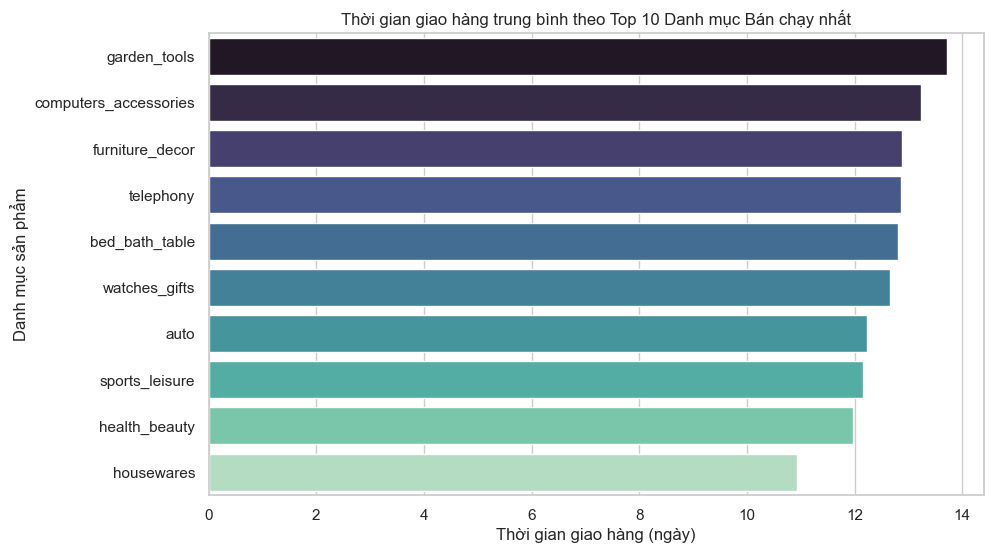

In [299]:
top_10_cats = df_final['product_category_name_english'].value_counts().nlargest(10).index 
df_top10_cat = df_final[df_final['product_category_name_english'].isin(top_10_cats)]
plt.figure(figsize=(10,6))
order = df_top10_cat.groupby('product_category_name_english')['target_delivery_days'].mean().sort_values(ascending=False).index 
sns.barplot(x='target_delivery_days', y='product_category_name_english', data=df_top10_cat, 
            order=order, palette='mako', ci=None)
plt.title('Thời gian giao hàng trung bình theo Top 10 Danh mục Bán chạy nhất')
plt.xlabel('Thời gian giao hàng (ngày)')
plt.ylabel('Danh mục sản phẩm')
plt.show()

#### `Nhận xét:`
- Nhóm giao hàng chậm nhất (Đồ điện tử & Nội thất): `computers_accessories (Phụ kiện máy tính)` và `furniture_decor (Nội thất/Trang trí)` dẫn đầu với thời gian giao hàng trung bình hơn 13 ngày.

    - Nguyên nhân: Đồ nội thất thường có kích thước cồng kềnh, quá khổ, bắt buộc phải dùng các dịch vụ vận chuyển chuyên biệt (xe tải lớn) thay vì bưu kiện tiêu chuẩn, dẫn đến thời gian chờ ghép chuyến lâu hơn. Phụ kiện máy tính thường là hàng điện tử giá trị cao, dễ vỡ, đòi hỏi quy trình đóng gói chống sốc khắt khe và đôi khi cần thủ tục bảo hiểm hàng hóa trước khi xuất kho.

- Nhóm giao hàng nhanh nhất (Hàng tiêu dùng nhỏ gọn): `housewares (Đồ gia dụng)`, `toys (Đồ chơi)` và `health_beauty (Sức khỏe & Sắc đẹp)` mất ít thời gian nhất `(chỉ khoảng 11 - 12 ngày)`.

    - Nguyên nhân: Đây là những mặt hàng tiêu chuẩn, kích thước nhỏ gọn, không yêu cầu bảo quản đặc biệt. Chúng dễ dàng được xử lý tự động, đóng gói nhanh và có thể vận chuyển bằng mọi phương tiện cơ bản (thậm chí là xe máy giao hàng).

### **i. Phân phối thời gian vận chuyển trên khắp các Bang khách hàng tại Brazil**

C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_3520\834783963.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='customer_state', y='target_delivery_days', data=df_final,
C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_3520\834783963.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_state', y='target_delivery_days', data=df_final,


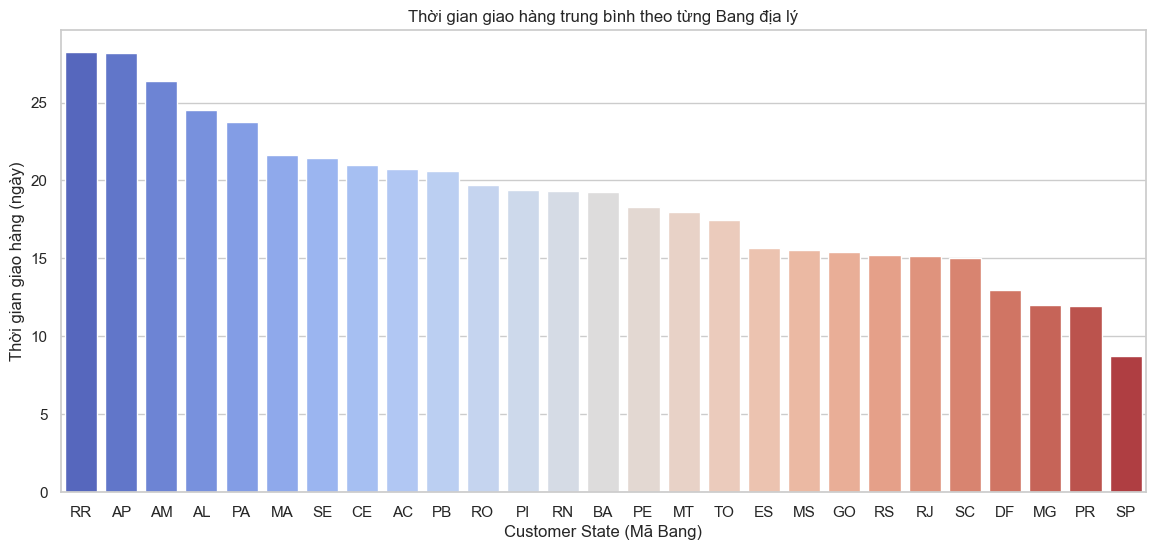

In [300]:
plt.figure(figsize=(14, 6))
# Sắp xếp các bang theo thời gian giao hàng trung bình giảm dần
state_order = df_final.groupby('customer_state')['target_delivery_days'].mean().sort_values(ascending=False).index

sns.barplot(x='customer_state', y='target_delivery_days', data=df_final, 
            order=state_order, palette='coolwarm', ci=None)
plt.title('Thời gian giao hàng trung bình theo từng Bang địa lý')
plt.xlabel('Customer State (Mã Bang)')
plt.ylabel('Thời gian giao hàng (ngày)')
plt.show()


#### `Nhận xét:`
- Nhóm `"Siêu tốc" (SP, PR, MG, RJ)`: Các bang như `São Paulo (SP), Paraná (PR), Minas Gerais (MG) và Rio de Janeiro (RJ)` có thời gian giao hàng thấp nhất `(khoảng 8 - 11 ngày)`.

    - Nguyên nhân: Đây là vùng tam giác kinh tế phía Đông Nam và Nam của Brazil. Hầu hết các kho hàng (warehouses) của người bán trên Olist tập trung tại `São Paulo`. Khoảng cách ngắn, hạ tầng đường bộ tốt và mật độ bưu cục dày đặc giúp việc giao hàng cực kỳ nhanh chóng.

- Nhóm `"Rùa bò" (RR, AP, AM, AL)`: Các bang vùng xa như `Roraima (RR), Amapá (AP), Amazonas (AM)` có thời gian giao hàng trung bình lên tới `25 - 30 ngày (gấp 3 lần vùng trung tâm)`.

    - Nguyên nhân: Đây là các bang thuộc vùng Amazon (phía Bắc) hoặc vùng ven biển phía Đông Bắc. Địa hình bị chia cắt bởi sông ngòi, rừng rậm, hạ tầng giao thông kém phát triển. Nhiều đơn hàng đến đây phải kết hợp cả đường bộ, đường thủy và đường hàng không, dẫn đến thời gian chờ đợi khủng khiếp.



### **j. Phân bố hiện trạng của ngoại lai (Outliers) đối với chi phí, kích cỡ và mục tiêu giao hàng**

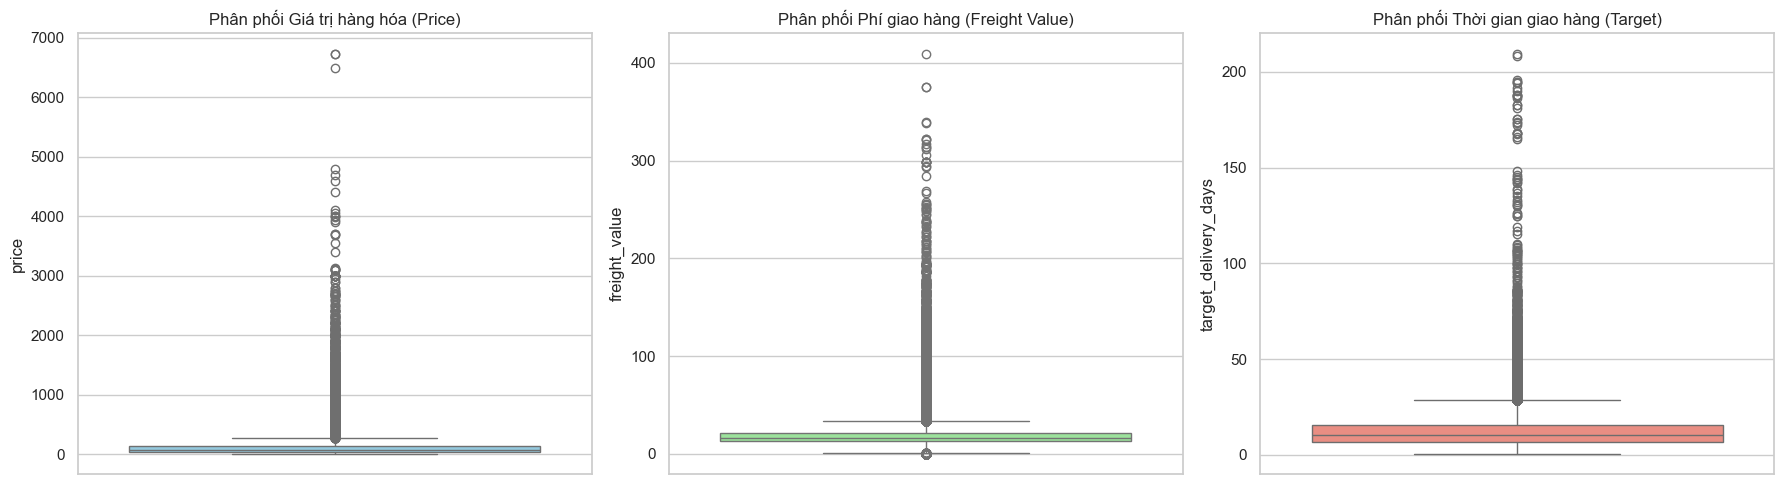

In [301]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Boxplot cho 3 giá trị liên tục cốt lõi
sns.boxplot(y=df_final['price'], ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Giá trị hàng hóa (Price)')
sns.boxplot(y=df_final['freight_value'], ax=axes[1], color='lightgreen')
axes[1].set_title('Phân phối Phí giao hàng (Freight Value)')
sns.boxplot(y=df_final['target_delivery_days'], ax=axes[2], color='salmon')
axes[2].set_title('Phân phối Thời gian giao hàng (Target)')
plt.tight_layout()
plt.show()


#### `Nhận xét:`

1. **Phân phối Giá trị hàng hóa (Price)**
- Hiện trạng: Thân hộp (chứa 50% dữ liệu ở giữa - IQR) bị ép chặt sát xuống đáy trục hoành. Trung vị (đường kẻ ngang trong hộp) nằm ở mức rất thấp, ước tính chỉ khoảng dưới $100$ BRL. Điều này chứng tỏ phần lớn khối lượng giao dịch trên Olist là các mặt hàng bình dân, giá rẻ.
- Ngoại lai: Rất dày đặc và kéo dài liên tục lên đến gần $7000$ BRL. Đây là những đơn hàng đặc biệt (ví dụ: đồ điện tử cao cấp, xe máy, máy móc công nghiệp).

2. **Phân phối Phí giao hàng (Freight Value)** - Yếu tố đại diện cho "Kích cỡ"
- Hiện trạng: Bạn có đề cập đến "kích cỡ", mặc dù biểu đồ không thể hiện trực tiếp thể tích/trọng lượng, nhưng freight_value tỷ lệ thuận trực tiếp với kích cỡ và khoảng cách. Trung vị phí vận chuyển dao động quanh mức $15 - 20$ BRL.Ngoại lai: Tương tự như giá, các điểm ngoại lai kéo dài lên mức $400$ BRL. Những ngoại lai này phản ánh hai trường hợp:Sản phẩm cực kỳ cồng kềnh, siêu nặng (đồ nội thất, giường tủ).Sản phẩm bị giao đến các khu vực địa lý hiểm trở, vùng sâu vùng xa (ví dụ vùng rừng Amazon của Brazil).

3. **Phân phối Thời gian giao hàng (Target_delivery_days)**
- Hiện trạng: Trung vị thời gian giao hàng nằm ở khoảng $10 - 15$ ngày. Phần lớn các đơn hàng (nằm trong râu của boxplot) được giao trong vòng dưới $30$ ngày.
- Ngoại lai: Dữ liệu có những điểm ngoại lai cực đoan lên tới hơn $200$ ngày (khoảng 7 tháng).

## **7. Tiền xử lý dữ liệu**
Trước khi tiền xử lý dữ liệu, bộ dữ liệu phải được đúng định dạng ở mỗi cột.

In [302]:
df_final = standardize_column_formats(df_final)

CHUẨN HÓA ĐỊNH DẠNG HOÀN TẤT


### **a. Xử lý missing values**

In [303]:
print("Thống kê số lượng giá trị còn thiếu ở mỗi cột:")
print(df_final.isnull().sum())

Thống kê số lượng giá trị còn thiếu ở mỗi cột:
order_purchase_timestamp          0
order_approved_at                15
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
shipping_limit_date               0
price                             0
freight_value                     0
seller_zip_code_prefix            0
seller_city                       0
seller_state                      0
product_weight_g                 18
product_length_cm                18
product_height_cm                18
product_width_cm                 18
product_category_name_english     0
target_delivery_days              0
month_year                        0
order_weekday                     0
order_month                       0
dtype: int64


- Xử lý giá trị thiếu ở 2 cột order_approved_at và order_delivered_carrier_date

In [304]:
df_final = optimize_logistics_timestamps(df_final)

Xử lý cột: order_approved_at
   + Số dòng đã điền: 15
   + Khoảng lệch trung vị (Median): 0.35 giờ
Xử lý cột: order_delivered_carrier_date
   + Số dòng đã điền: 1
   + Khoảng lệch trung vị (Median): 44.06 giờ


- Xử lý giá trị thiếu ở các cột kích thước sản phẩm

In [305]:
df_final = fill_product_specs_smart(df_final)

 XỬ LÝ KÍCH THƯỚC & TRỌNG LƯỢNG 
 Cột product_weight_g: Đã điền 18 dòng. (Global Median dùng: 700.0)
 Cột product_length_cm: Đã điền 18 dòng. (Global Median dùng: 25.0)
 Cột product_height_cm: Đã điền 18 dòng. (Global Median dùng: 13.0)
 Cột product_width_cm: Đã điền 18 dòng. (Global Median dùng: 20.0)


- Xử lý giá trị thiếu ở cột phân loại sản phẩm

In [306]:
df_final = handle_category_missing(df_final)

XỬ LÝ DANH MỤC 
 Đã điền 0 dòng trống bằng nhãn 'other'.


### **b. Xử lý duplicate**

In [307]:
df_final =handle_duplicates(df_final)

XỬ LÝ TRÙNG LẶP HOÀN TẤT
- Số lượng dòng trùng lặp đã xóa: 10,219
- Kích thước dữ liệu sau khi xóa: (99970, 23)


### **c. Phát hiện và xử lý ngoại lai**

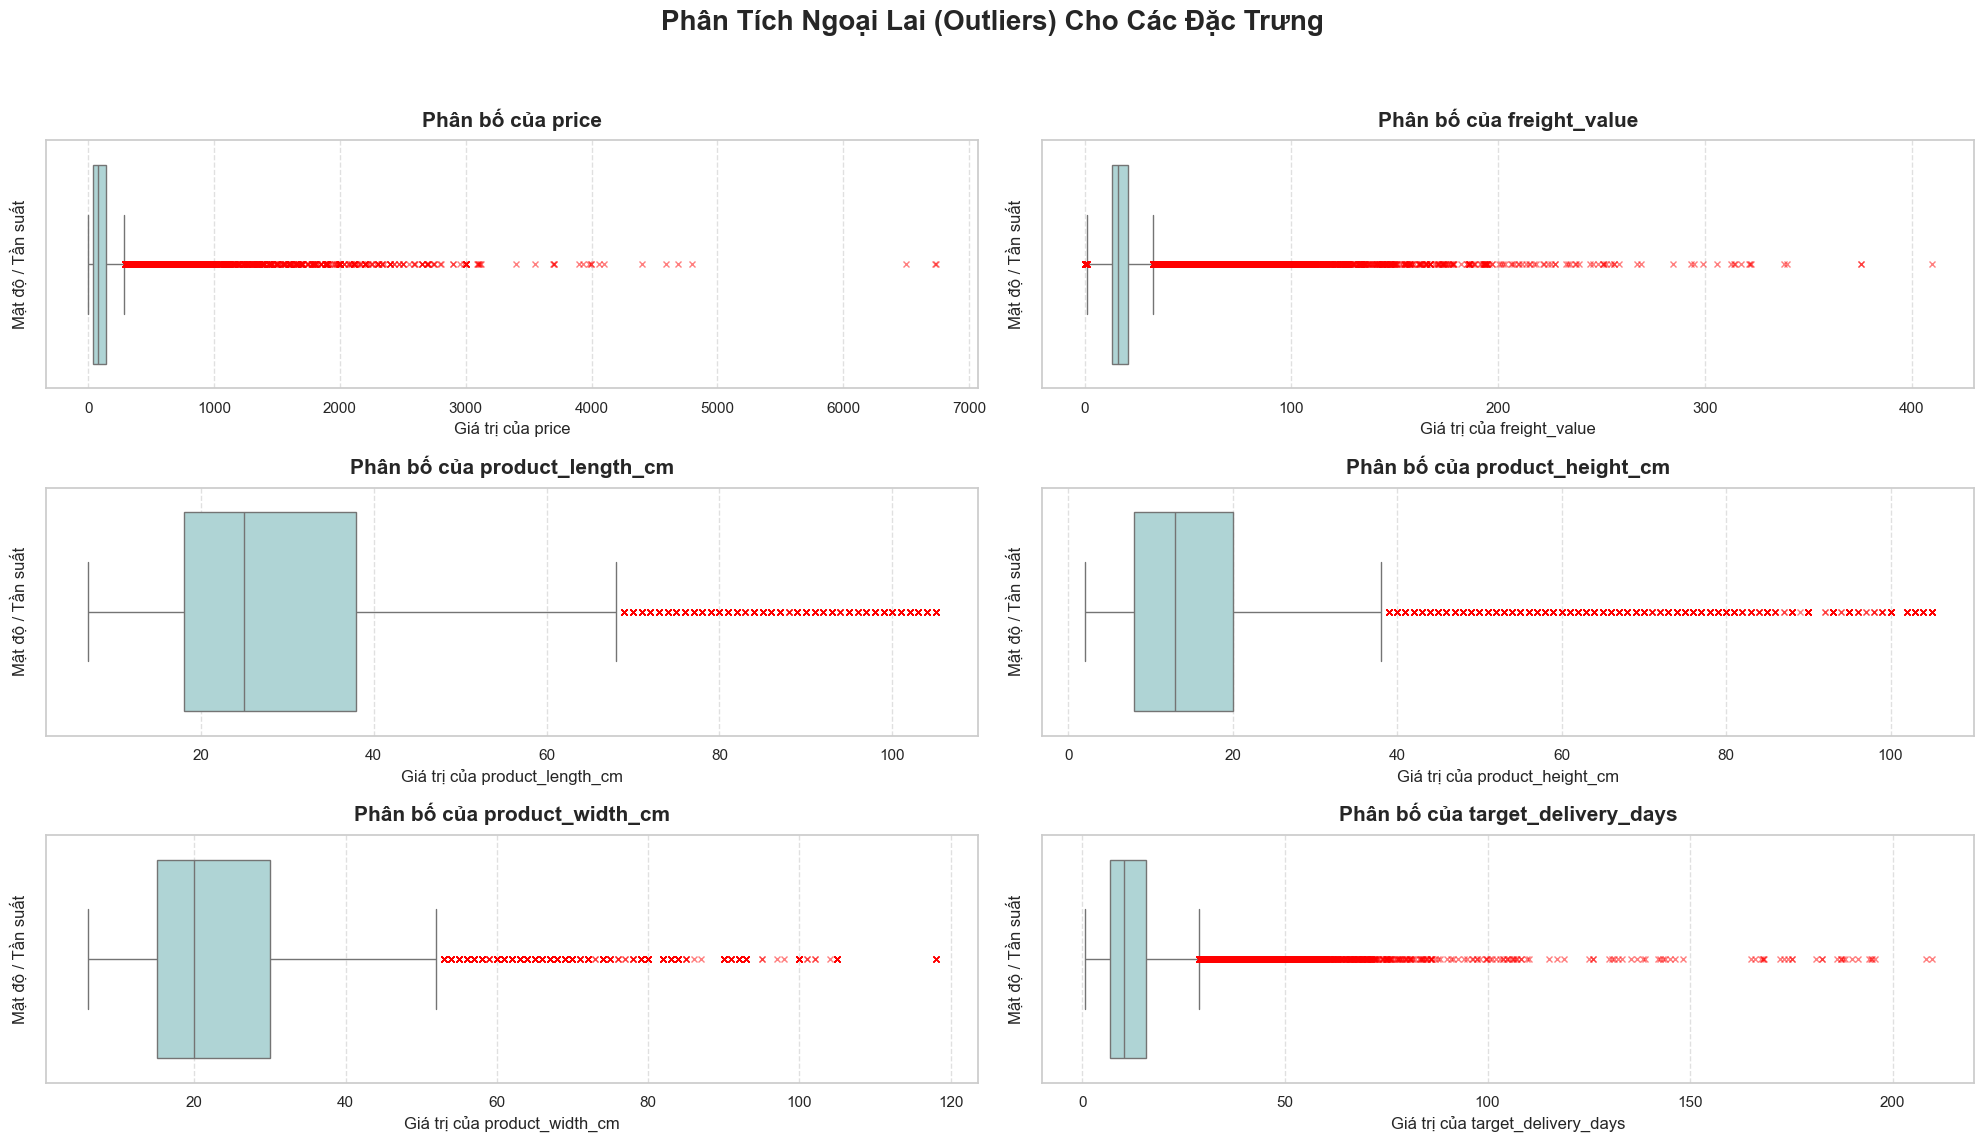

In [308]:
cols_to_check = ['price', 'freight_value', 'product_length_cm', 
                 'product_height_cm', 'product_width_cm', 'target_delivery_days']

visualize_outliers(df_final, cols_to_check)

##### Nhận xét
* **Dữ liệu lệch phải nặng:** Đa số là hàng rẻ/giao nhanh, nhưng "đuôi" ngoại lai rất dài.
* **Nhiễu Target cực đoan:** Có đơn hàng giao > 150 ngày, đây là lỗi cần loại bỏ.

##### Hướng giải quyết
1.  **`target_delivery_days`**: Dùng **IQR** (Loại bỏ nhiễu thô).
2.  **`price`, `freight_value`**: Dùng **Log Transform** (Nén biến tài chính).
3.  **`product_length/height/width`**: Dùng **Isolation Forest** (Lọc kích thước đa biến).


In [309]:
df_cleaned = handle_outliers_pipeline(df_final)

Đã loại bỏ ngoại lai Target (IQR). Dữ liệu còn lại: 94771 dòng.
Đã nén biến Price và Freight Value bằng Log Transform.
Isolation Forest đã loại bỏ thêm 4735 dòng ngoại lai đa biến.
Tổng dữ liệu sạch: 90036 dòng.


## **8. Chia dữ liệu và Feature Engineering**

### **a. Chia tập dữ liệu**

In [310]:
def preprocess_and_split_pipeline(df, target_col='target_delivery_days', test_size=0.20, val_size=0.10, random_state=42): 
    """
        Pipeline xử lý: Split -> Feature -> Feature Fit 
        Đảm bảo ko xảy ra Data Leakage
    """
    df_clean = df.copy()

    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col].values
    X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=test_size, random_state=random_state)
    val_frac = val_size / (1.0-test_size)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_frac, random_state=random_state)
    return X_train, X_val, X_test, y_train, y_val, y_test

TARGET = 'target_delivery_days'

X_train, X_val, X_test, y_train, y_val, y_test = preprocess_and_split_pipeline(
    df_cleaned, 
    target_col=TARGET, 
    test_size=0.20,    
    val_size=0.10,      
    random_state=42     
)

print(f"Số lượng mẫu tập Train: {X_train.shape[0]} ({X_train.shape[0]/len(df_cleaned):.0%})")
print(f"Số lượng mẫu tập Val:   {X_val.shape[0]} ({X_val.shape[0]/len(df_cleaned):.0%})")
print(f"Số lượng mẫu tập Test:  {X_test.shape[0]} ({X_test.shape[0]/len(df_cleaned):.0%})")

Số lượng mẫu tập Train: 63024 (70%)
Số lượng mẫu tập Val:   9004 (10%)
Số lượng mẫu tập Test:  18008 (20%)


### **b. Feature Engineering**
- Tính toán khoảng cách địa lý

In [311]:
geo_df = pd.read_csv(f'{path}/olist_geolocation_dataset.csv')
X_train = merge_geolocation_and_calculate_distance(X_train, geo_df)
X_val = merge_geolocation_and_calculate_distance(X_val, geo_df)
X_test = merge_geolocation_and_calculate_distance(X_test, geo_df)

 Hoàn thành trích xuất đặc trưng 'distance_km'
 Hoàn thành trích xuất đặc trưng 'distance_km'
 Hoàn thành trích xuất đặc trưng 'distance_km'


- Tính toán thể tích sản phẩm

In [312]:
def calculate_product_volume(df):
    """
    Tính toán thể tích sản phẩm từ chiều dài, chiều cao và chiều rộng.
    Công thức: Volume = Length * Height * Width
    """
    d_opt = df.copy()
    
    dim_cols = ['product_length_cm', 'product_height_cm', 'product_width_cm']
    
    if set(dim_cols).issubset(d_opt.columns):
        d_opt['product_volume_cm3'] = (
            d_opt['product_length_cm'] * d_opt['product_height_cm'] * d_opt['product_width_cm']
        )
        
        d_opt.drop(columns=dim_cols, inplace=True, errors='ignore')
        
        print(f"Đã tạo biến 'product_volume_cm3' cho {df.name if hasattr(df, 'name') else 'DataFrame'}")
    else:
        missing = list(set(dim_cols) - set(d_opt.columns))
        print(f"Thiếu các cột sau để tính thể tích: {missing}")
        
    return d_opt

X_train = calculate_product_volume(X_train)
X_val = calculate_product_volume(X_val)
X_test = calculate_product_volume(X_test)

Đã tạo biến 'product_volume_cm3' cho DataFrame
Đã tạo biến 'product_volume_cm3' cho DataFrame
Đã tạo biến 'product_volume_cm3' cho DataFrame


### **c. Mã hóa biến phân loại**
- Mã hóa biến thứ/ tháng.

In [313]:
def apply_cyclical_encoding(df):
    d_opt = df.copy()
    
    if 'order_weekday' in d_opt.columns:
        weekday_map = {
            'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 
            'Friday': 4, 'Saturday': 5, 'Sunday': 6
        }
        if d_opt['order_weekday'].dtype == 'object':
            d_opt['order_weekday'] = d_opt['order_weekday'].map(weekday_map)
            

        d_opt['weekday_sin'] = np.sin(2 * np.pi * d_opt['order_weekday'] / 7)
        d_opt['weekday_cos'] = np.cos(2 * np.pi * d_opt['order_weekday'] / 7)

        d_opt.drop(columns=['order_weekday'], inplace=True)

    if 'order_month' in d_opt.columns:
        month_num = pd.to_numeric(d_opt['order_month'], errors='coerce')
        
        # Tính toán Sin-Cos
        d_opt['month_sin'] = np.sin(2 * np.pi * month_num / 12)
        d_opt['month_cos'] = np.cos(2 * np.pi * month_num / 12)
        
        d_opt.drop(columns=['order_month'], inplace=True)
        
    return d_opt
X_train = apply_cyclical_encoding(X_train)
X_val = apply_cyclical_encoding(X_val)
X_test = apply_cyclical_encoding(X_test)

- Mã hóa biến ngành hàng

In [314]:
def apply_ohe_top10_category(X_train, X_val, X_test, column='product_category_name_english'):
    """
    Xử lý mã hóa One-Hot cho cột Ngành hàng:
    1. Lọc Top 10 từ tập Train.
    2. Gom các nhóm còn lại vào 'Other'.
    3. Mã hóa One-Hot (drop='first') để tránh đa tuyến.
    """
    X_train_res = X_train.copy()
    X_val_res = X_val.copy()
    X_test_res = X_test.copy()

    # XÁC ĐỊNH TOP 10 (Chỉ dựa trên tập TRAIN)
    top_10_cats = X_train_res[column].value_counts().nlargest(10).index.tolist()
    
    # MAPPING 'OTHER' 
    def map_func(x):
        return x if x in top_10_cats else 'Other'
    
    X_train_res[column] = X_train_res[column].apply(map_func)
    X_val_res[column] = X_val_res[column].apply(map_func)
    X_test_res[column] = X_test_res[column].apply(map_func)

    # ONE-HOT ENCODING 
    ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    
    ohe.fit(X_train_res[[column]])
    
    new_feature_names = ohe.get_feature_names_out([column])
    
    train_encoded = pd.DataFrame(ohe.transform(X_train_res[[column]]), columns=new_feature_names, index=X_train.index)
    val_encoded = pd.DataFrame(ohe.transform(X_val_res[[column]]), columns=new_feature_names, index=X_val.index)
    test_encoded = pd.DataFrame(ohe.transform(X_test_res[[column]]), columns=new_feature_names, index=X_test.index)

    X_train_final = pd.concat([X_train_res.drop(columns=[column]), train_encoded], axis=1)
    X_val_final = pd.concat([X_val_res.drop(columns=[column]), val_encoded], axis=1)
    X_test_final = pd.concat([X_test_res.drop(columns=[column]), test_encoded], axis=1)

    print(f"Đã xử lý One-Hot cho {column}")
    print(f"Top 10 ngành hàng: {top_10_cats}")
    
    return X_train_final, X_val_final, X_test_final
X_train, X_val, X_test = apply_ohe_top10_category(X_train, X_val, X_test, column='product_category_name_english')

Đã xử lý One-Hot cho product_category_name_english
Top 10 ngành hàng: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'computers_accessories', 'furniture_decor', 'housewares', 'watches_gifts', 'telephony', 'toys', 'garden_tools']


- Tính VIF để kiếm tra cộng đa tuyến mới phát sinh

In [315]:
vif_full_report = calculate_full_vif(X_train)

print(vif_full_report)

                                              feature       VIF
3                                    product_weight_g  2.290484
5                                  product_volume_cm3  2.213726
2                                       freight_value  1.945187
4                                         distance_km  1.526925
1                                               price  1.362675
19        product_category_name_english_watches_gifts  1.191517
14        product_category_name_english_health_beauty  1.171813
10       product_category_name_english_bed_bath_table  1.160853
11  product_category_name_english_computers_access...  1.143116
16       product_category_name_english_sports_leisure  1.126057
15           product_category_name_english_housewares  1.121374
17            product_category_name_english_telephony  1.116204
12      product_category_name_english_furniture_decor  1.108268
18                 product_category_name_english_toys  1.077304
13         product_category_name_english

##### **Nhận xét kết quả VIF:**
* Toàn bộ các đặc trưng đều có chỉ số $VIF < 2.5$, thấp hơn nhiều so với ngưỡng cảnh báo ($VIF > 5$).
* Không có hiện tượng đa tuyến nghiêm trọng xảy ra giữa các biến số logistics (`weight`, `volume`, `freight`) và các biến phân loại đã mã hóa.
* **Kết luận:** Bộ đặc trưng hiện tại hoàn toàn thỏa mãn giả thiết về tính độc lập tuyến tính của mô hình Gauss-Markov, sẵn sàng cho bước huấn luyện mô hình.


### **d. Chuẩn hóa dữ liệu**

In [316]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer
import pandas as pd

def optimize_scaling_pipeline(X_train, X_val, X_test):
    """
    - Biến lệch & Tương tác: Dùng QuantileTransformer.
    - Biến chu kỳ/ổn định: Dùng StandardScaler.
    """
    
    all_columns = X_train.columns.tolist()
    
    skewed_features = ['price', 'freight_value', 'distance_km', 'product_volume_cm3']
    skewed_features = [c for c in skewed_features if c in all_columns]
    
    stable_features = ['month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
    stable_features = [c for c in stable_features if c in all_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            ('quantile', QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42), skewed_features),
            ('std', StandardScaler(), stable_features)
        ],
        remainder='passthrough' 
    )

    preprocessor.fit(X_train)

    remaining_cols = [c for c in all_columns if c not in (skewed_features + stable_features)]
    final_feature_names = skewed_features + stable_features + remaining_cols

    def transform_data(df):
        return pd.DataFrame(preprocessor.transform(df), columns=final_feature_names, index=df.index)

    return transform_data(X_train), transform_data(X_val), transform_data(X_test), preprocessor

X_train_encoded, X_val_encoded, X_test_encoded, scaler_pipeline = optimize_scaling_pipeline(X_train, X_val, X_test)

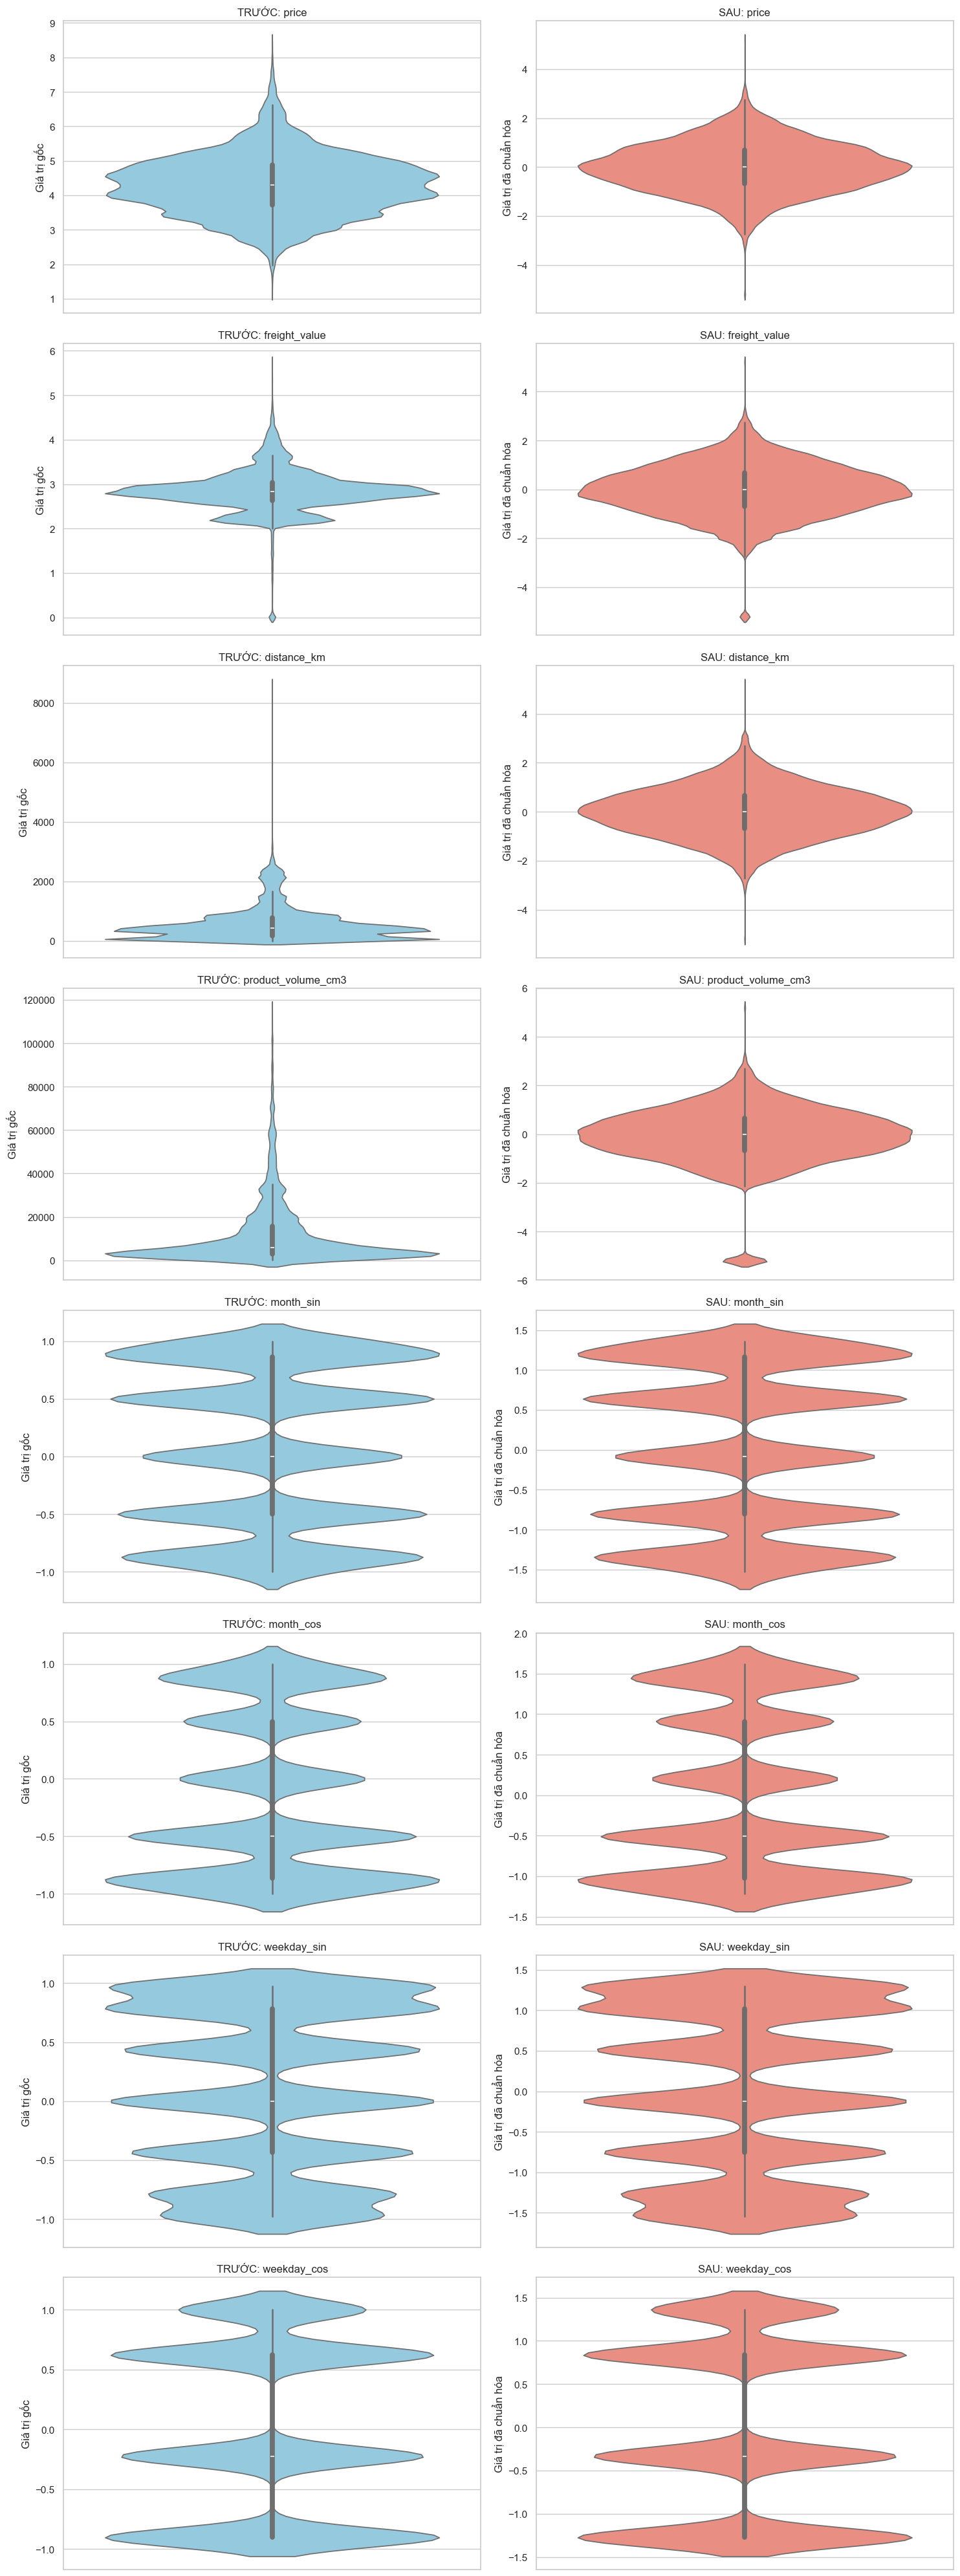

In [317]:
cols = ['price','freight_value', 'distance_km', 'product_volume_cm3', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
plot_violin_comparison(X_train, X_train_encoded, cols)

##### **Nhận xét chuẩn hóa dữ liệu**
* **Biến lệch (Price, Freight, Distance, Volume):** Đã chuyển từ lệch phải sang **phân phối chuẩn (Gaussian)** bằng `QuantileTransformer`, giúp thỏa mãn giả thiết hồi quy và ổn định hóa sai số.
* **Biến chu kỳ (Sin-Cos):** Đồng nhất thang đo bằng `StandardScaler` mà vẫn giữ nguyên đặc tính phân phối thời gian.
* **Kết luận:** Dữ liệu đã cùng **Scale**, giúp thuật toán **Gradient Descent** hội tụ nhanh và **Regularization** (Lasso/Ridge) hoạt động công bằng, chính xác.

### **f. Lựa chọn đặc trưng**

##### Đặc trưng được lựa chọn (Selected)

| Nhóm | Đặc trưng tiêu biểu | Lý do lựa chọn (Core Reason) |
| :--- | :--- | :--- |
| **Logistics** | `distance_km`, `freight_value` | Biến cốt lõi quyết định thời gian vận chuyển thực tế. |
| **Vật lý** | `volume_cm3`, `weight_g` | Phản ánh độ cồng kềnh, tác động đến khâu điều phối phương tiện. |
| **Thời gian** | `month_sin/cos` | Tập trung khai thác **tính mùa vụ** (Seasonal effects) quan trọng nhất. |
| **Phân loại** | `product_category_...` | Phân hóa quy trình xử lý riêng cho từng nhóm hàng đặc thù. |


##### Đặc trưng bị loại bỏ (Excluded)

| Nhóm | Đặc trưng | Lý do loại bỏ (Justification) |
| :--- | :--- | :--- |
| **Dữ liệu thô** | `timestamps`, `month_year` | Dạng chuỗi không tính toán được; đã được trích xuất thông tin. |
| **Địa danh** | `customer_city`, `seller_state` | High Cardinality (quá nhiều giá trị) dễ gây nhiễu và Overfitting. |
| **Kinh tế** | `price` | Tương quan cao với phí vận chuyển nhưng ít tác động đến tốc độ xe. |
| **Thời gian (Tuần)**| `weekday_sin/cos` | **Mối liên hệ tuyến tính yếu**; tinh giản để mô hình tập trung vào các biến chính. |

**Biến mục tiêu:** `target_delivery_days` — Số ngày từ lúc xác nhận đơn hàng đến lúc nhận hàng thực tế (đơn vị: ngày).

In [318]:
# Danh sách các cột số và đã mã hóa
selected_features = [
    'freight_value', 'distance_km', 'product_volume_cm3', 'product_weight_g',
    'month_sin', 'month_cos'
] + [c for c in X_train.columns if 'product_category_name_english_' in c]

X_train_final = X_train[selected_features].astype(float)
X_val_final   = X_val[selected_features].astype(float)
X_test_final  = X_test[selected_features].astype(float)

print(f"Dữ liệu đã sẵn sàng với {X_train_final.shape[1]} đặc trưng số!")

Dữ liệu đã sẵn sàng với 16 đặc trưng số!


In [319]:
def save_processed_data(X_train, X_val, X_test, y_train, y_val, y_test, folder_path=f'{path}processed'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    
    train_full = X_train.copy()
    train_full['target_delivery_days'] = y_train
    
    val_full = X_val.copy()
    val_full['target_delivery_days'] = y_val
    
    test_full = X_test.copy()
    test_full['target_delivery_days'] = y_test
    
    train_full.to_csv(f'{folder_path}/train_final.csv', index=False)
    val_full.to_csv(f'{folder_path}/val_final.csv', index=False)
    test_full.to_csv(f'{folder_path}/test_final.csv', index=False)
    
    print(f" Đã lưu dữ liệu vào thư mục '{folder_path}'")
    print(f"   - Train: {train_full.shape}")
    print(f"   - Val:   {val_full.shape}")
    print(f"   - Test:  {test_full.shape}")

save_processed_data(X_train_final, X_val_final, X_test_final, y_train, y_val, y_test)

 Đã lưu dữ liệu vào thư mục '../../data/processed'
   - Train: (63024, 17)
   - Val:   (9004, 17)
   - Test:  (18008, 17)


### **9. Trực quan hóa dữ liệu sau xử lý**

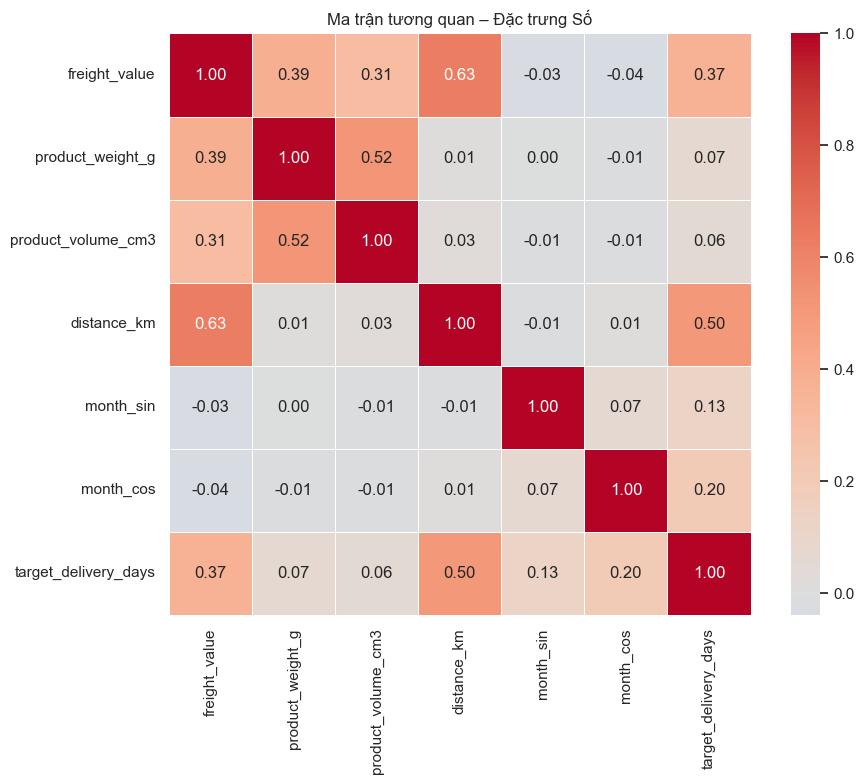

In [320]:
df_corr = X_train_encoded.copy()
df_corr['target_delivery_days'] = y_train

numeric_cols_new = [
    'freight_value', 'product_weight_g', 'product_volume_cm3',
    'distance_km', 'month_sin', 'month_cos', 
    'target_delivery_days'
]

valid_cols = [c for c in numeric_cols_new if c in df_corr.columns]
corr_matrix = df_corr[valid_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Ma trận tương quan – Đặc trưng Số')
plt.tight_layout()
plt.show()


### `Trích chọn + Chuẩn hóa đặc trưng`

In [321]:
# y = df_ml['target_delivery_days'].values
# # 1. SCALE CÁC CỘT LIÊN TỤC BỊ LỆCH PHẢI 
# features_to_scale = [
#     'product_weight_g', 'product_length_cm', 'product_height_cm', 
#     'product_width_cm', 'distance_km'
# ]
# features_to_scale = [col for col in features_to_scale if col in df_ml.columns]
# df_ml_scaled = transform_and_scale_features(df_ml, features_to_scale)
# # 2. LỌC ĐẶC TRƯNG + ONE-HOT ENCODING
# numeric_features = ['price', 'freight_value',
#     'product_weight_g', 'product_length_cm', 'product_height_cm', 
#     'product_width_cm', 'distance_km']
# categorical_features = ['customer_state', 'seller_state', 'product_category_name_english', 'order_weekday', 'order_month']
# numeric_features   = [col for col in numeric_features   if col in df_ml_scaled.columns]
# categorical_features = [col for col in categorical_features if col in df_ml_scaled.columns]


# for col in ['order_weekday', 'order_month']:
#     if col in df_ml_scaled[col]:
#         df_ml_scaled[col] = df_ml_scaled.astype(str)


# df_features = df_ml_scaled[numeric_features + categorical_features].copy()
# df_encoded  = pd.get_dummies(df_features, columns=categorical_features, drop_first=True, dtype=int)
# feature_names = df_encoded.columns.tolist()
# X = df_encoded.values
# print(f"Tổng số features: {X.shape[1]}")
# # 3. CHIA TẬP 70 / 10 / 20
# X_temp, X_test, y_temp, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=42
# )
# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.125, random_state=42
# )
# total = X.shape[0]
# print(f"\nTrain : {X_train.shape[0]:>6} mẫu ({X_train.shape[0]/total*100:.0f}%)")
# print(f"Val   : {X_val.shape[0]:>6} mẫu ({X_val.shape[0]/total*100:.0f}%)")
# print(f"Test  : {X_test.shape[0]:>6} mẫu ({X_test.shape[0]/total*100:.0f}%)")


def preprocess_and_split_pipeline(df, target_col='target_delivery_days', test_size=0.20, val_size=0.10, random_state=42): 
    """
        Pipeline xử lý: Split -> Feature -> Feature Fit 
        Đảm bảo ko xảy ra Data Leakage
    """
    df_clean = df.copy()

    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col].values
    X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=test_size, random_state=random_state)
    val_frac = val_size / (1.0-test_size)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_frac, random_state=random_state)

def engineer_features(data): 
    d_opt = data.copy()
    if set(['product_length_cm', 'product_height_cm', 'product_width_cm']).issubset(d_opt.columns): 
       d_opt['product_volume_cm3'] = d_opt['product_length_cm'] * d_opt['product_height_cm'] * d_opt['product_width_cm']
       d_opt.drop(columns=['product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True, errors='ignore') 
    
    cols_drop_geo = ['customer_state', 'seller_state']
    d_opt.drop(columns=[c for c in cols_drop_geo if c in d_opt.columns], inplace=True, errors='ignore')
    if 'order_weekday' in d_opt.columns:
            d_opt['is_weekend'] = d_opt['order_weekday'].apply(lambda x: 1 if x >= 5 else 0)
        
    if 'order_month' in d_opt.columns:
        d_opt['month_sin'] = np.sin(2 * np.pi * d_opt['order_month'] / 12)
        d_opt['month_cos'] = np.cos(2 * np.pi * d_opt['order_month'] / 12)
        
    d_opt.drop(columns=['order_weekday', 'order_month'], inplace=True, errors='ignore')
    return d_opt
#X_train = engineer_features(X_train)
#X_val   = engineer_features(X_val)
#X_test  = engineer_features(X_test)


In [322]:
def preprocess_and_split_pipeline(df, target_col='target_delivery_days', test_size=0.20, val_size=0.10, random_state=42):
    """
    Pipeline xử lý chuẩn ML: Split trước -> Feature Engineering -> Feature Fit Transform
    Đảm bảo 100% No Data Leakage.
    """
    df_clean = df.copy()
    
    # -------------------------------------------------------------
    # BƯỚC 1: CHIA TẬP ĐỘC LẬP TRƯỚC TIÊN (NGĂN CHẶN LEAKAGE)
    # -------------------------------------------------------------
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col].values
    
    # Chia theo test_size = 0.20
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Tính tỉ lệ thực tế của Validation set.
    val_frac = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_frac, random_state=random_state)

    # -------------------------------------------------------------
    # BƯỚC 2: FEATURE ENGINEERING DÒNG (Không lệ thuộc chéo, áp dụng an toàn)
    # -------------------------------------------------------------
    def engineer_features(data):
        d_opt = data.copy()
        
        # 1. Thể tích (Duy trì thể tích - thay thế cho cân nặng)
        if set(['product_length_cm', 'product_height_cm', 'product_width_cm']).issubset(d_opt.columns):
            d_opt['product_volume_cm3'] = d_opt['product_length_cm'] * d_opt['product_height_cm'] * d_opt['product_width_cm']
            d_opt.drop(columns=['product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True, errors='ignore')
            
        # 2. Địa lý
        cols_drop_geo = ['customer_state', 'seller_state']
        d_opt.drop(columns=[c for c in cols_drop_geo if c in d_opt.columns], inplace=True, errors='ignore')
        
        # 3. Thời gian 
        # Đã lược bỏ logic tính is_weekend theo kết quả loại nhiễu.
        if 'order_month' in d_opt.columns:
            # Ép kiểu tháng về dạng Window Numeric chắc chắn để tính sin/cos
            month_num = pd.to_numeric(d_opt['order_month'], errors='coerce')
            d_opt['month_sin'] = np.sin(2 * np.pi * month_num / 12)
            d_opt['month_cos'] = np.cos(2 * np.pi * month_num / 12)
            
        d_opt.drop(columns=['order_weekday', 'order_month'], inplace=True, errors='ignore')
        
        return d_opt

    X_train = engineer_features(X_train)
    X_val   = engineer_features(X_val)
    X_test  = engineer_features(X_test)

    # -------------------------------------------------------------
    # BƯỚC 3: XỬ LÝ NHÓM (DỰA TRÊN THÔNG KÊ CHỈ TỪ TẬP TRAIN)
    # -------------------------------------------------------------
    if 'product_category_name_english' in X_train.columns:
        # TÌM TOP 10 DANH MỤC CHỈ TRÊN TẬP TRAIN
        top_10_cats = X_train['product_category_name_english'].value_counts().nlargest(10).index
        
        # Mapping Category (Áp dụng Top 10 của Train cho cả Val và Test)
        map_func = lambda x: x if x in top_10_cats else 'Other'
        X_train['product_category_name_english'] = X_train['product_category_name_english'].apply(map_func)
        X_val['product_category_name_english']   = X_val['product_category_name_english'].apply(map_func)
        X_test['product_category_name_english']  = X_test['product_category_name_english'].apply(map_func)

    # -------------------------------------------------------------
    # BƯỚC 4: SCALE & TRANFORM BẰNG COLUMN_TRANSFORMER
    # -------------------------------------------------------------
    # [CẬP NHẬT QUAN TRỌNG]: Đã xóa 'price', 'product_weight_g' và 'is_weekend'. 
    # Mọi biến không xuất hiện trong mảng này sẽ bị bộ Transform tự động gác bỏ.
    num_features = ['freight_value', 'product_volume_cm3', 'distance_km', 'month_sin', 'month_cos']
    num_features = [c for c in num_features if c in X_train.columns]
    
    cat_features = ['product_category_name_english']
    cat_features = [c for c in cat_features if c in X_train.columns]

    # Preprocessor xử lý Scale và OHE độc lập
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_features),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
        ],
        remainder='drop' # Tự động xóa các biến thừa đã bị loại từ EDA
    )
    
    # FIT CHỈ TRÊN TRAIN
    preprocessor.fit(X_train)
    
    # Lấy feature names mới nhất từ Preprocessor rẽ nhánh
    cat_encoder = preprocessor.named_transformers_['cat']
    feature_names = num_features + list(cat_encoder.get_feature_names_out(cat_features))
    
    # TRANSFORM TRÊN CẢ 3 TẬP 
    X_train_final = pd.DataFrame(preprocessor.transform(X_train), columns=feature_names, index=X_train.index)
    X_val_final   = pd.DataFrame(preprocessor.transform(X_val), columns=feature_names, index=X_val.index)
    X_test_final  = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names, index=X_test.index)

    # In ra thông tin
    total = X.shape[0]
    print(f"Tổng số features của mô hình đầu vào: {X_train_final.shape[1]}")
    print(f"Train Set: {X_train_final.shape[0]:>6} mẫu ({X_train_final.shape[0]/total*100:.0f}%)")
    print(f"Val Set  : {X_val_final.shape[0]:>6} mẫu ({X_val_final.shape[0]/total*100:.0f}%)")
    print(f"Test Set : {X_test_final.shape[0]:>6} mẫu ({X_test_final.shape[0]/total*100:.0f}%)")
    
    return X_train_final, X_val_final, X_test_final, y_train, y_val, y_test, preprocessor

# ==============================================================
# GỌI HÀM THỰC THI
# ==============================================================
#X_train, X_val, X_test, y_train, y_val, y_test, preprocessor = preprocess_and_split_pipeline(df_ml, test_size=0.20, val_size=0.10)


### Bảng tổng hợp đặc trưng đầu vào (Sau Tối Ưu Hóa & Lựa Chọn Cuối Cùng)

| Đặc trưng | Loại | Mô tả | Chi tiết Xử lý |
|-----------|------|-------|-------|
| `freight_value` | Liên tục | Phí vận tải (BRL) - Đại diện gián tiếp cho bài toán Logistics. | Standardization |
| `product_volume_cm3` | Liên tục | Thể tích của sản phẩm ($Dài \times Rộng \times Cao$). Giữ lại làm đại diện cho sự cồng kềnh. | Standardization |
| `distance_km` | Liên tục | Khoảng cách Haversine từ kho người bán đến nhà người mua (km). | Standardization |
| `product_category_name_english` | Phân loại | Danh mục sản phẩm bán hàng (Tiếng Anh). | Lọc Top 10 + "Other" $\rightarrow$ One-Hot Encoding |
| `month_sin`, `month_cos` | Liên tục | Khai thác tính Mùa Vụ. Mã hóa hàm Lượng Giác giúp bảo toàn tính chu kỳ thời gian (Tháng 12 nối liền về Tháng 1). | Trực tiếp (Pass-through) |

**Biến mục tiêu:** `target_delivery_days` — Số ngày từ lúc xác nhận đơn hàng đến lúc nhận hàng thực tế (đơn vị: ngày).

--- 
**Các đặc trưng đã được phân tích và LƯỢC BỎ (Dựa trên EDA và Tránh Đa Cộng Tuyến):**
- **Trọng lượng & Kích thước thô (`product_weight_g`, `length_cm`, `width_cm`, `height_cm`):** Kích thước 3D đã được quy đổi thành cấu trúc Thể tích. Cột cân nặng (`product_weight_g`) bị lược bỏ triệt để vì có Đa cộng tuyến (Multicollinearity) quá cao ($r = 0.72$) với thể tích, dễ làm sai lệch trọng số biến trong mô hình Hồi quy.
- **Biến nhiễu phi tuyến tính (`price`, `is_weekend`):** Có hệ số tương quan tuyến tính với Target cực kỳ thấp ($r = 0.04$ và $r = 0.01$). Về mặt Logic: *Giá trị món đồ đắt/rẻ* không làm tài xế giao nhanh hơn; và ảnh hưởng *chênh lệch 1-2 ngày cuối tuần* đã bị pha loãng hoàn toàn vào chu kỳ Logistics kéo dài 10-15 ngày.
- **Nhóm Địa lý danh nghĩa (`customer_state`, `seller_state`):** Chứa thông tin chồng chéo nhưng lại sinh ra quá nhiều chiều dữ liệu thưa (số lượng Sparse Data cao) nếu dùng OHE. Sự ảnh hưởng của địa lý đã được nội suy xuất sắc qua quãng đường vật lý `distance_km`.
- **Nhóm thời gian gốc (`order_month`, `order_weekday`):** Đã xóa bỏ tận gốc để không sinh ra bẫy biến giả r


## **Trực quan hóa các đặc trưng sau khi xử lí**

### a. Heatmap tương quan

### `Nhận xét:`

- Triệt tiêu Đa cộng tuyến (Multicollinearity): Đã loại bỏ product_weight_g (tương quan 0.72 với thể tích) và các chiều vật lý mộc để giữ lại duy nhất đại diện không gian là product_volume_cm3.

- Lọc nhiễu & Tránh ma trận thưa (Sparsity): Xóa bỏ các đặc trưng có tín hiệu yếu (price, is_weekend) và nhóm địa lý danh nghĩa (customer_state, seller_state) do đã được nội suy hoàn hảo bởi biến liên tục distance_km. Danh mục sản phẩm được gom nhóm (Top 10 + Other) để tránh tạo ra hàng chục cột OHE vô giá trị.

- Bảo toàn Tín hiệu Lõi (Core Signals): Tập trung vào cấu trúc Logistics cốt lõi gồm: Khoảng cách (distance_km), Cước phí (freight_value), Độ cồng kềnh (volume), Chu kỳ mùa vụ (month_sin, month_cos) và Loại hàng hóa chính.

### `Lưu ra file CSV`

In [323]:
#process_path = os.path.join(path,"processed")
#os.makedirs(process_path, exist_ok=True)

# Chỉ việc sử dụng trực tiếp X_train, X_val, X_test (vì nó TRƯỚC ĐÓ ĐÃ LÀ DATAFRAME rồi)
#df_train = X_train.copy()
#df_train['target_delivery_days'] = y_train 

#df_val = X_val.copy()
#df_val['target_delivery_days'] = y_val

#df_test = X_test.copy()
#df_test['target_delivery_days'] = y_test

# Lưu vào csv 
#df_train.to_csv(os.path.join(process_path, "train.csv"), index=False)
#df_val.to_csv(os.path.join(process_path, "val.csv"), index=False)
#df_test.to_csv(os.path.join(process_path, "test.csv"), index=False)

#print(f"Số lượng đặc trưng Train thực tế: {df_train.shape[1]} cột")
#print(f"Đã lưu thành công vào file csv!")
